In [1]:
import requests

url = "https://www.cbioportal.org/api/studies"
studies = requests.get(url).json()

print(len(studies))       # how many studies in total
print(studies[0])         # look at the first one

548
{'studyId': 'breast_msk_2026', 'cancerTypeId': 'breast', 'name': 'CCNE1 Amplifications in Breast Cancer (MSK, 2026)', 'description': 'Targeted Sequencing of 6,318 breast cancer samples and their matched normals via MSK-IMPACT to investigate the clinicopathologic characteristics and prognostic implications of CCNE1 amplifications in breast cancer across receptor subtypes.', 'publicStudy': True, 'groups': '', 'status': 0, 'importDate': '2026-09-21 18:49:27', 'allSampleCount': 6318, 'referenceGenome': 'hg19', 'readPermission': True, 'resourceCounts': []}


In [2]:
pancan = []

for study in studies:
    if study["studyId"].endswith("_tcga_pan_can_atlas_2018"):
        pancan.append(study)

print(len(pancan))

for study in pancan:
    print(study["name"])

32
Brain Lower Grade Glioma (TCGA, PanCancer Atlas)
Liver Hepatocellular Carcinoma (TCGA, PanCancer Atlas)
Lung Adenocarcinoma (TCGA, PanCancer Atlas)
Lung Squamous Cell Carcinoma (TCGA, PanCancer Atlas)
Mesothelioma (TCGA, PanCancer Atlas)
Ovarian Serous Cystadenocarcinoma (TCGA, PanCancer Atlas)
Pancreatic Adenocarcinoma (TCGA, PanCancer Atlas)
Pheochromocytoma and Paraganglioma (TCGA, PanCancer Atlas)
Prostate Adenocarcinoma (TCGA, PanCancer Atlas)
Sarcoma (TCGA, PanCancer Atlas)
Skin Cutaneous Melanoma (TCGA, PanCancer Atlas)
Stomach Adenocarcinoma (TCGA, PanCancer Atlas)
Testicular Germ Cell Tumors (TCGA, PanCancer Atlas)
Thyroid Carcinoma (TCGA, PanCancer Atlas)
Thymoma (TCGA, PanCancer Atlas)
Uterine Corpus Endometrial Carcinoma (TCGA, PanCancer Atlas)
Uterine Carcinosarcoma (TCGA, PanCancer Atlas)
Uveal Melanoma (TCGA, PanCancer Atlas)
Adrenocortical Carcinoma (TCGA, PanCancer Atlas)
Breast Invasive Carcinoma (TCGA, PanCancer Atlas)
Cervical Squamous Cell Carcinoma (TCGA, PanCa

In [7]:
url = "https://www.cbioportal.org/api/molecular-profiles/brca_tcga_pan_can_atlas_2018_mutations/mutations"
params = {"sampleListId": "brca_tcga_pan_can_atlas_2018_all", "entrezGeneId": 7157}
muts = requests.get(url, params=params).json()
print("Breast cancer p53 mutations:", len(muts))

for m in muts:
    if m["proteinChange"] == "R273H":
        print(m)
        break

Breast cancer p53 mutations: 353
{'uniqueSampleKey': 'VENHQS1BMi1BMDRULTAxOmJyY2FfdGNnYV9wYW5fY2FuX2F0bGFzXzIwMTg', 'uniquePatientKey': 'VENHQS1BMi1BMDRUOmJyY2FfdGNnYV9wYW5fY2FuX2F0bGFzXzIwMTg', 'molecularProfileId': 'brca_tcga_pan_can_atlas_2018_mutations', 'sampleId': 'TCGA-A2-A04T-01', 'patientId': 'TCGA-A2-A04T', 'entrezGeneId': 7157, 'studyId': 'brca_tcga_pan_can_atlas_2018', 'center': '.', 'mutationStatus': '.', 'validationStatus': '.', 'tumorAltCount': 174, 'tumorRefCount': 108, 'normalAltCount': 0, 'normalRefCount': 256, 'chr': '17', 'startPosition': 7577120, 'endPosition': 7577120, 'referenceAllele': 'C', 'variantAllele': 'T', 'proteinChange': 'R273H', 'mutationType': 'Missense_Mutation', 'ncbiBuild': 'GRCh37', 'variantType': 'SNP', 'refseqMrnaId': 'NM_001126112.2', 'proteinPosStart': 273, 'proteinPosEnd': 273, 'keyword': 'TP53 R273 missense'}


In [8]:
import requests
import pandas as pd

# 1. Get every study on cBioPortal
studies = requests.get("https://www.cbioportal.org/api/studies").json()
print("All studies:", len(studies))

# 2. Keep only the 32 TCGA PanCancer Atlas studies
pancan = []
for study in studies:
    if study["studyId"].endswith("_tcga_pan_can_atlas_2018"):
        pancan.append(study)
print("PanCancer Atlas studies:", len(pancan))

# 3. Test on breast cancer: find one R273H mutation
url = "https://www.cbioportal.org/api/molecular-profiles/brca_tcga_pan_can_atlas_2018_mutations/mutations"
params = {"sampleListId": "brca_tcga_pan_can_atlas_2018_all", "entrezGeneId": 7157}
muts = requests.get(url, params=params).json()
print("Breast cancer p53 mutations:", len(muts))

for m in muts:
    if m["proteinChange"] == "R273H":
        print(m)
        break

# 4. Download p53 mutations from all 32 cancer types
rows = []
for study in pancan:
    sid = study["studyId"]
    url = f"https://www.cbioportal.org/api/molecular-profiles/{sid}_mutations/mutations"
    params = {"sampleListId": f"{sid}_all", "entrezGeneId": 7157}

    muts = requests.get(url, params=params).json()
    print(sid, len(muts))

    for m in muts:
        rows.append({
            "cancer_type": study["name"],
            "sample": m["sampleId"],
            "protein_change": m["proteinChange"],
            "mutation_type": m["mutationType"],
            "residue": m["proteinPosStart"]
        })

# 5. Turn it into a table and save it
df = pd.DataFrame(rows)
df.to_csv("tp53_mutations_raw.csv", index=False)
print(len(df), "total mutations")
df.head()

All studies: 548
PanCancer Atlas studies: 32
Breast cancer p53 mutations: 353
{'uniqueSampleKey': 'VENHQS1BMi1BMDRULTAxOmJyY2FfdGNnYV9wYW5fY2FuX2F0bGFzXzIwMTg', 'uniquePatientKey': 'VENHQS1BMi1BMDRUOmJyY2FfdGNnYV9wYW5fY2FuX2F0bGFzXzIwMTg', 'molecularProfileId': 'brca_tcga_pan_can_atlas_2018_mutations', 'sampleId': 'TCGA-A2-A04T-01', 'patientId': 'TCGA-A2-A04T', 'entrezGeneId': 7157, 'studyId': 'brca_tcga_pan_can_atlas_2018', 'center': '.', 'mutationStatus': '.', 'validationStatus': '.', 'tumorAltCount': 174, 'tumorRefCount': 108, 'normalAltCount': 0, 'normalRefCount': 256, 'chr': '17', 'startPosition': 7577120, 'endPosition': 7577120, 'referenceAllele': 'C', 'variantAllele': 'T', 'proteinChange': 'R273H', 'mutationType': 'Missense_Mutation', 'ncbiBuild': 'GRCh37', 'variantType': 'SNP', 'refseqMrnaId': 'NM_001126112.2', 'proteinPosStart': 273, 'proteinPosEnd': 273, 'keyword': 'TP53 R273 missense'}
lgg_tcga_pan_can_atlas_2018 319
lihc_tcga_pan_can_atlas_2018 113
luad_tcga_pan_can_atlas_2

,cancer_type,sample,protein_change,mutation_type,residue
0,"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-4938-01,R248W,Missense_Mutation,248
1,"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-4942-01,C275F,Missense_Mutation,275
2,"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-4943-01,Y220C,Missense_Mutation,220
3,"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-5393-01,P250L,Missense_Mutation,250
4,"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-5396-01,R273H,Missense_Mutation,273


In [9]:
# Keep only missense mutations
missense = df[df["mutation_type"] == "Missense_Mutation"].copy()

# Remove duplicates (same mutation listed twice for the same tumour)
missense = missense.drop_duplicates(subset=["sample", "protein_change"])

# Make sure residue numbers are whole numbers
missense["residue"] = missense["residue"].astype(int)

print("All mutations:", len(df))
print("Missense mutations:", len(missense))
print("Tumours with a missense mutation:", missense["sample"].nunique())
print("Cancer types:", missense["cancer_type"].nunique())

All mutations: 4225
Missense mutations: 2731
Tumours with a missense mutation: 2544
Cancer types: 30


In [10]:
set(df["cancer_type"]) - set(missense["cancer_type"])

{'Thyroid Carcinoma (TCGA, PanCancer Atlas)'}

In [11]:
counts = missense["residue"].value_counts()
counts.head(10)

,count
residue,
273,267
248,224
175,167
245,91
282,89
220,75
179,69
193,64
158,50


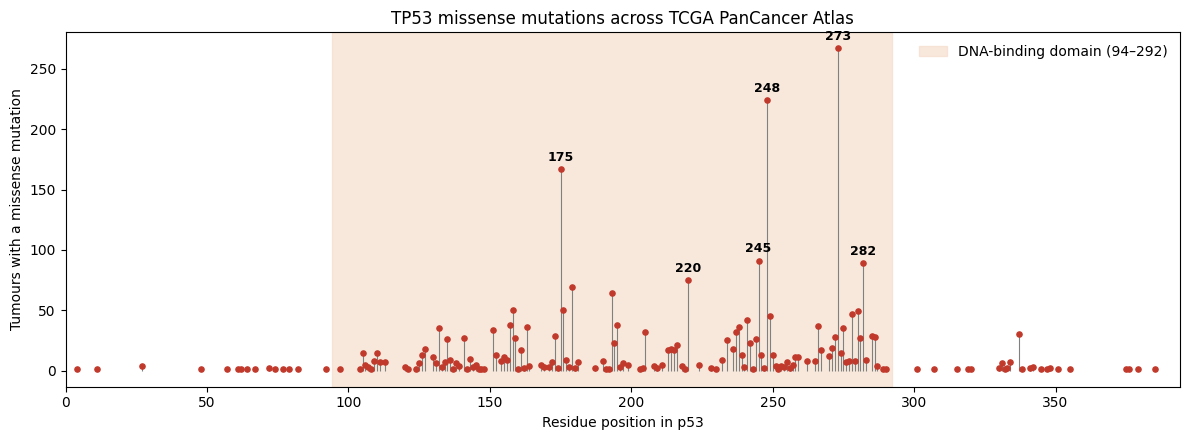

In [12]:
import matplotlib.pyplot as plt

counts = missense["residue"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4.5))

# Shade the DNA-binding domain
ax.axvspan(94, 292, color="#f4d9c6", alpha=0.6, label="DNA-binding domain (94–292)")

# Draw the lollipops
ax.vlines(counts.index, 0, counts.values, color="gray", linewidth=0.8)
ax.scatter(counts.index, counts.values, s=14, color="#c0392b", zorder=3)

# Label the top 6 hotspots
for res, n in counts.sort_values(ascending=False).head(6).items():
    ax.annotate(str(res), (res, n), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=9, fontweight="bold")

ax.set_xlim(0, 394)
ax.set_xlabel("Residue position in p53")
ax.set_ylabel("Tumours with a missense mutation")
ax.set_title("TP53 missense mutations across TCGA PanCancer Atlas")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("fig1_lollipop.png", dpi=200)
plt.show()